# Data protocol (read before re-running)

**This notebook must be re-run top to bottom.** Any outputs still stored below were
produced by the earlier version, in which the RL reward and the layer-sensitivity
probe were computed on test images; those numbers are optimistically biased and
should not be cited.

Splits used now:

| Split | Size | Used for |
|---|---|---|
| `train_loader` | 45,000 (CIFAR-10 train) | all weight updates |
| `val_loader` / `small_val_loader` | 5,000 / 1,000 (CIFAR-10 train, held out) | layer sensitivity, RL reward |
| `test_loader` | 10,000 (CIFAR-10 test) | one final measurement per reported method |

`train_env` is scored on `small_val_loader`, so the agent is never optimised
against the test set; `eval_env` produces the single reported test number.

1. Imports & Config

In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

os.makedirs("../checkpoints", exist_ok=True)
os.makedirs("../results", exist_ok=True)

Using device: cpu


2. Dataset Loading

In [3]:
# ---------------------------------------------------------------------------
# Data splits (no test-set leakage)
#
#   train_dataset : 45,000 CIFAR-10 training images -> all weight updates
#   val_dataset   :  5,000 CIFAR-10 training images -> layer sensitivity and
#                                                      the RL reward signal
#   test_dataset  : 10,000 CIFAR-10 test images     -> touched ONCE, only for
#                                                      the final reported numbers
# ---------------------------------------------------------------------------

VAL_SIZE = 5000  # held-out validation images taken from the train split

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

# Same 50,000 images, two views: augmented (for training) and plain (for evaluation).
cifar_train_augmented = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform_train
)

cifar_train_plain = torchvision.datasets.CIFAR10(
    root="../data",
    train=True,
    download=True,
    transform=transform_test
)

split_generator = torch.Generator().manual_seed(SEED)
permuted_indices = torch.randperm(len(cifar_train_augmented), generator=split_generator).tolist()

train_indices = permuted_indices[:-VAL_SIZE]
val_indices = permuted_indices[-VAL_SIZE:]

assert not (set(train_indices) & set(val_indices)), "train/val split overlaps"

train_dataset = Subset(cifar_train_augmented, train_indices)
val_dataset = Subset(cifar_train_plain, val_indices)  # evaluation view: no random crop/flip

test_dataset = torchvision.datasets.CIFAR10(
    root="../data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 45000
Val size: 5000
Test size: 10000


In [4]:
# Fast probe set for layer sensitivity and the RL reward.
# These are held-out TRAINING images, not test images, so nothing the agent
# is rewarded on can leak into the final reported accuracy.
RL_PROBE_SIZE = 1000

small_val_dataset = Subset(cifar_train_plain, val_indices[:RL_PROBE_SIZE])

small_val_loader = DataLoader(
    small_val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("Small validation size:", len(small_val_dataset))

Small validation size: 1000


3. CNN Model

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # features.0
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # features.3
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # features.6
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),                 # classifier.1
            nn.ReLU(),
            nn.Linear(256, 10)                           # classifier.3
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

4. Train & Evaluate Baseline

In [6]:
def train_model(model, train_loader, criterion, optimizer, device, epochs=10):
    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {avg_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.2f}%"
        )

In [7]:
def evaluate_model(model, data_loader, device, print_result=True):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    if print_result:
        print(f"Accuracy: {accuracy:.2f}%")

    return accuracy

In [8]:
baseline_model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

train_model(
    model=baseline_model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10
)

# Validation accuracy drives the RL reward; test accuracy is measured once and
# only ever reported.
baseline_val_accuracy = evaluate_model(baseline_model, val_loader, device, print_result=False)
baseline_accuracy = evaluate_model(baseline_model, test_loader, device, print_result=False)

print(f"Baseline validation accuracy: {baseline_val_accuracy:.2f}%")
print(f"Baseline test accuracy (reported): {baseline_accuracy:.2f}%")

Epoch [1/10] Loss: 1.6048 | Train Accuracy: 40.81%


Epoch [2/10] Loss: 1.2453 | Train Accuracy: 55.26%


Epoch [3/10] Loss: 1.0620 | Train Accuracy: 62.01%


Epoch [4/10] Loss: 0.9391 | Train Accuracy: 66.74%


Epoch [5/10] Loss: 0.8616 | Train Accuracy: 69.73%


...

Epoch [7/10] Loss: 0.7518 | Train Accuracy: 73.60%


Epoch [8/10] Loss: 0.7139 | Train Accuracy: 74.89%


Epoch [9/10] Loss: 0.6880 | Train Accuracy: 75.91%


Epoch [10/10] Loss: 0.6524 | Train Accuracy: 77.19%


Baseline validation accuracy: 77.32%
Baseline test accuracy (reported): 77.03%


5. Save & Reload Baseline Checkpoint

In [9]:
baseline_checkpoint_path = "../checkpoints/cnn_baseline_FIXED.pth"

torch.save(baseline_model.state_dict(), baseline_checkpoint_path)
print("Saved baseline model:", baseline_checkpoint_path)

Saved baseline model: ../checkpoints/cnn_baseline_FIXED.pth


In [10]:
baseline_model = SimpleCNN().to(device)
baseline_model.load_state_dict(torch.load(baseline_checkpoint_path, map_location=device))
baseline_model.eval()

baseline_val_accuracy = evaluate_model(baseline_model, val_loader, device, print_result=False)
baseline_accuracy = evaluate_model(baseline_model, test_loader, device, print_result=False)

print(f"Reloaded baseline | Val: {baseline_val_accuracy:.2f}% | Test: {baseline_accuracy:.2f}%")

Reloaded baseline | Val: 77.32% | Test: 77.03%


6. Detect Prunable Layers

In [11]:
def get_prunable_layers(model):
    prunable_layers = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            prunable_layers.append((name, module))

    return prunable_layers

In [12]:
prunable_layers_all = get_prunable_layers(baseline_model)

for i, (name, layer) in enumerate(prunable_layers_all):
    print(f"{i}: {name} | {type(layer).__name__} | Params: {layer.weight.numel()}")

0: features.0 | Conv2d | Params: 864
1: features.3 | Conv2d | Params: 18432
2: features.6 | Conv2d | Params: 73728
3: classifier.1 | Linear | Params: 524288
4: classifier.3 | Linear | Params: 2560


In [13]:
prunable_layers_filtered = [
    (name, layer)
    for name, layer in prunable_layers_all
    if name != "classifier.3"
]

print("Filtered prunable layers:")
for i, (name, layer) in enumerate(prunable_layers_filtered):
    print(f"{i}: {name} | {type(layer).__name__} | Params: {layer.weight.numel()}")

Filtered prunable layers:
0: features.0 | Conv2d | Params: 864
1: features.3 | Conv2d | Params: 18432
2: features.6 | Conv2d | Params: 73728
3: classifier.1 | Linear | Params: 524288


7. Pruning Utilities

In [14]:
def apply_global_pruning_fresh(model, amount):
    pruned_model = copy.deepcopy(model)

    parameters_to_prune = []

    for module in pruned_model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, "weight"))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount
    )

    return pruned_model

In [15]:
def apply_layer_pruning_by_name_inplace(model, layer_name, amount):
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, (nn.Conv2d, nn.Linear)):
            prune.l1_unstructured(module, name="weight", amount=amount)
            return model

    raise ValueError(f"Layer {layer_name} not found or not prunable")

In [16]:
def calculate_sparsity(model):
    total_params = 0
    zero_params = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight

            total_params += weight.nelement()
            zero_params += torch.sum(weight == 0).item()

    sparsity = 100.0 * zero_params / total_params
    return sparsity

8. Manual Pruning Baselines

In [ ]:
def test_global_magnitude_pruning(model, pruning_levels, eval_loader, device):
    """Global magnitude (L1) pruning: rank ALL weights together and remove the
    smallest, letting the per-layer allocation fall out of the weight statistics.

    This is NOT uniform per-layer pruning -- the two are separate baselines and
    behave very differently. Note it also prunes classifier.3, which the RL
    action space excludes.
    """
    results = []

    for amount in pruning_levels:
        print(f"\nTesting Global Magnitude Pruning: {amount * 100:.0f}%")

        pruned_model = apply_global_pruning_fresh(model, amount=amount).to(device)

        accuracy = evaluate_model(pruned_model, eval_loader, device)
        sparsity = calculate_sparsity(pruned_model)

        print(f"Accuracy: {accuracy:.2f}% | Sparsity: {sparsity:.2f}%")

        results.append({
            "Method": f"Global Magnitude {int(amount * 100)}%",
            "Actions": "-",
            "Accuracy (%)": accuracy,
            "Sparsity (%)": sparsity
        })

    return pd.DataFrame(results)

In [ ]:
global_magnitude_levels = [0.1, 0.2, 0.4, 0.6, 0.8]

global_magnitude_df = test_global_magnitude_pruning(
    model=baseline_model,
    pruning_levels=global_magnitude_levels,
    eval_loader=test_loader,
    device=device
)

global_magnitude_df

9. Layer Sensitivity

In [19]:
def compute_layer_sensitivities(model, prunable_layers, data_loader, device, probe_amount=0.1):
    sensitivities = {}

    base_accuracy = evaluate_model(model, data_loader, device, print_result=False)

    print("Small validation baseline accuracy:", base_accuracy)

    for layer_name, _layer in prunable_layers:
        temp_model = copy.deepcopy(model)
        temp_model = apply_layer_pruning_by_name_inplace(
            temp_model,
            layer_name,
            probe_amount
        ).to(device)

        pruned_accuracy = evaluate_model(
            temp_model,
            data_loader,
            device,
            print_result=False
        )

        accuracy_drop = base_accuracy - pruned_accuracy

        sensitivities[layer_name] = accuracy_drop

        print(
            f"{layer_name}: "
            f"Accuracy after pruning = {pruned_accuracy:.2f}% | "
            f"Sensitivity/drop = {accuracy_drop:.4f}"
        )

    return sensitivities

In [20]:
layer_sensitivities = compute_layer_sensitivities(
    model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    data_loader=small_val_loader,
    device=device,
    probe_amount=0.1
)

layer_sensitivities

Small validation baseline accuracy: 76.1


features.0: Accuracy after pruning = 75.50% | Sensitivity/drop = 0.6000


features.3: Accuracy after pruning = 75.90% | Sensitivity/drop = 0.2000


features.6: Accuracy after pruning = 76.00% | Sensitivity/drop = 0.1000


classifier.1: Accuracy after pruning = 76.10% | Sensitivity/drop = 0.0000


{'features.0': 0.5999999999999943,
 'features.3': 0.19999999999998863,
 'features.6': 0.09999999999999432,
 'classifier.1': 0.0}

10. Action Space

In [21]:
ACTION_TO_PRUNE = {
    0: 0.0,
    1: 0.1,
    2: 0.2,
    3: 0.3,
    4: 0.4,
    5: 0.6
}

print(ACTION_TO_PRUNE)

{0: 0.0, 1: 0.1, 2: 0.2, 3: 0.3, 4: 0.4, 5: 0.6}


11. State Representation

In [22]:
def extract_layer_state(
    layer,
    layer_index,
    total_layers,
    cumulative_pruning,
    layer_name=None,
    layer_sensitivities=None
):
    weights = layer.weight.detach().cpu()

    sensitivity = 0.0

    if layer_name is not None and layer_sensitivities is not None:
        sensitivity = layer_sensitivities.get(layer_name, 0.0)

    state = {
        "layer_index": layer_index,
        "total_layers": total_layers,
        "param_count": weights.numel(),
        "mean_abs_weight": weights.abs().mean().item(),
        "std_weight": weights.std().item(),
        "cumulative_pruning": cumulative_pruning,
        "sensitivity": sensitivity
    }

    return state

In [23]:
MAX_PARAM_COUNT = max(
    layer.weight.numel()
    for _name, layer in prunable_layers_all
)

print("MAX_PARAM_COUNT:", MAX_PARAM_COUNT)

MAX_PARAM_COUNT: 524288


In [24]:
def state_to_vector(state):
    return np.array([
        state["layer_index"] / max(1, state["total_layers"] - 1),
        np.log1p(state["param_count"]),
        state["param_count"] / MAX_PARAM_COUNT,
        state["mean_abs_weight"],
        state["std_weight"],
        state["cumulative_pruning"],
        state["sensitivity"]
    ], dtype=np.float32)

In [25]:
test_name, test_layer = prunable_layers_filtered[0]

test_state = extract_layer_state(
    layer=test_layer,
    layer_index=0,
    total_layers=len(prunable_layers_filtered),
    cumulative_pruning=0.0,
    layer_name=test_name,
    layer_sensitivities=layer_sensitivities
)

test_vector = state_to_vector(test_state)

print(test_state)
print(test_vector)
print(test_vector.shape)

{'layer_index': 0, 'total_layers': 4, 'param_count': 864, 'mean_abs_weight': 0.11525052040815353, 'std_weight': 0.1355205476284027, 'cumulative_pruning': 0.0, 'sensitivity': 0.5999999999999943}
[0.0000000e+00 6.7627296e+00 1.6479492e-03 1.1525052e-01 1.3552055e-01
 0.0000000e+00 6.0000002e-01]
(7,)


12. Reward Function

In [26]:
def compute_reward(final_accuracy, baseline_accuracy, sparsity, actions=None):
    accuracy_ratio = final_accuracy / baseline_accuracy

    reward = (
        1.5 * accuracy_ratio +
        0.04 * sparsity
    )

    if actions is not None:
        diversity_bonus = 0.05 * len(set(actions))
        reward += diversity_bonus

    return reward

13. Gym Environment

In [27]:
class CompressionEnvGym(gym.Env):
    def __init__(
        self,
        base_model,
        prunable_layers,
        baseline_accuracy,
        eval_loader,
        device,
        layer_sensitivities=None
    ):
        super().__init__()

        self.base_model = base_model
        self.prunable_layers_info = [
            (name, type(layer).__name__)
            for name, layer in prunable_layers
        ]

        self.total_layers = len(prunable_layers)
        self.baseline_accuracy = baseline_accuracy
        self.eval_loader = eval_loader
        self.device = device
        self.layer_sensitivities = layer_sensitivities if layer_sensitivities is not None else {}

        self.action_space = spaces.Discrete(len(ACTION_TO_PRUNE))

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(7,),
            dtype=np.float32
        )

        self.current_layer_index = 0
        self.current_model = None
        self.cumulative_pruning = 0.0
        self.actions_taken = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_layer_index = 0
        self.current_model = copy.deepcopy(self.base_model)
        self.cumulative_pruning = 0.0
        self.actions_taken = []

        observation = self._get_state()
        info = {}

        return observation, info

    def _get_state(self):
        if self.current_layer_index >= self.total_layers:
            return np.zeros((7,), dtype=np.float32)

        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        for name, module in self.current_model.named_modules():
            if name == layer_name:
                state = extract_layer_state(
                    layer=module,
                    layer_index=self.current_layer_index,
                    total_layers=self.total_layers,
                    cumulative_pruning=self.cumulative_pruning,
                    layer_name=name,
                    layer_sensitivities=self.layer_sensitivities
                )

                return state_to_vector(state)

        raise ValueError(f"Layer {layer_name} not found in current model")

    def step(self, action):
        action = int(action)

        prune_amount = ACTION_TO_PRUNE[action]
        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        self.current_model = apply_layer_pruning_by_name_inplace(
            self.current_model,
            layer_name,
            prune_amount
        )

        self.actions_taken.append(action)
        self.cumulative_pruning += prune_amount
        self.current_layer_index += 1

        terminated = self.current_layer_index >= self.total_layers
        truncated = False

        if terminated:
            final_accuracy = evaluate_model(
                self.current_model,
                self.eval_loader,
                self.device,
                print_result=False
            )

            final_sparsity = calculate_sparsity(self.current_model)

            reward = compute_reward(
                final_accuracy=final_accuracy,
                baseline_accuracy=self.baseline_accuracy,
                sparsity=final_sparsity,
                actions=self.actions_taken
            )

            observation = np.zeros((7,), dtype=np.float32)

            info = {
                "final_accuracy": final_accuracy,
                "final_sparsity": final_sparsity,
                "reward": reward,
                "actions": self.actions_taken
            }

        else:
            reward = 0.0
            observation = self._get_state()

            info = {
                "current_layer": layer_name,
                "prune_amount": prune_amount
            }

        return observation, reward, terminated, truncated, info

In [28]:
# Smoke test on the training-side env: reward is measured on held-out
# validation images, so its baseline must be the validation baseline.
gym_env = CompressionEnvGym(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_val_accuracy,
    eval_loader=small_val_loader,
    device=device,
    layer_sensitivities=layer_sensitivities
)

obs, info = gym_env.reset()
result = gym_env.step(2)

print("Observation shape:", obs.shape)
print("Step output length:", len(result))
print(result)

Observation shape: (7,)
Step output length: 5
(array([0.33333334, 9.8218975 , 0.03515625, 0.05391617, 0.06901219,
       0.2       , 0.2       ], dtype=float32), 0.0, False, False, {'current_layer': 'features.0', 'prune_amount': 0.2})


In [29]:
check_env(gym_env, warn=True)
print("Environment check passed.")

Environment check passed.


14. Fixed Policy Evaluation

In [ ]:
def run_fixed_policy(policy, policy_name, prunable_layers, eval_loader):
    """Apply a fixed per-layer pruning policy, one action per layer.

    The step index is tracked explicitly. It must NOT be derived from
    info["actions"], which the environment only populates on the terminal step:
    that made every layer receive policy[0], which is invisible for a uniform
    policy and silently wrong for any non-uniform one.
    """
    if len(policy) != len(prunable_layers):
        raise ValueError(
            f"policy has {len(policy)} actions but there are "
            f"{len(prunable_layers)} prunable layers"
        )

    env = CompressionEnvGym(
        base_model=baseline_model,
        prunable_layers=prunable_layers,
        baseline_accuracy=baseline_accuracy,
        eval_loader=eval_loader,
        device=device,
        layer_sensitivities=layer_sensitivities
    )

    obs, info = env.reset()
    done = False
    step_idx = 0

    while not done:
        obs, reward, terminated, truncated, info = env.step(policy[step_idx])
        step_idx += 1
        done = terminated or truncated

    return {
        "Method": policy_name,
        "Actions": str(policy),
        "Accuracy (%)": info["final_accuracy"],
        "Sparsity (%)": info["final_sparsity"],
        "Reward": info["reward"]
    }

In [31]:
filtered_manual_results = []

filtered_manual_results.append(
    run_fixed_policy([2, 2, 2, 2], "Filtered Uniform 20%", prunable_layers_filtered, test_loader)
)

filtered_manual_results.append(
    run_fixed_policy([4, 4, 4, 4], "Filtered Uniform 40%", prunable_layers_filtered, test_loader)
)

filtered_manual_results.append(
    run_fixed_policy([5, 5, 5, 5], "Filtered Uniform 60%", prunable_layers_filtered, test_loader)
)

filtered_manual_df = pd.DataFrame(filtered_manual_results)
filtered_manual_df

,Method,Actions,Accuracy (%),Sparsity (%),Reward
0,Filtered Uniform 20%,"[2, 2, 2, 2]",75.69,19.917499,2.320606
1,Filtered Uniform 40%,"[4, 4, 4, 4]",67.75,39.834837,2.962685
2,Filtered Uniform 60%,"[5, 5, 5, 5]",40.48,59.752175,3.228351


15. PPO Agent Evaluation Function

In [32]:
def evaluate_trained_agent(agent, eval_env, policy_name):
    obs, info = eval_env.reset()

    done = False
    chosen_actions = []

    while not done:
        action, _states = agent.predict(obs, deterministic=True)
        action = int(action)

        chosen_actions.append(action)

        obs, reward, terminated, truncated, info = eval_env.step(action)

        done = terminated or truncated

    result = {
        "Method": policy_name,
        "Actions": str(chosen_actions),
        "Accuracy (%)": info["final_accuracy"],
        "Sparsity (%)": info["final_sparsity"],
        "Reward": info["reward"]
    }

    print(policy_name, result)

    return result

16. PPO Training

In [33]:
# Training env: scored on held-out validation images only.
train_env = CompressionEnvGym(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_val_accuracy,
    eval_loader=small_val_loader,
    device=device,
    layer_sensitivities=layer_sensitivities
)

# Evaluation env: the single final test measurement for the learned policy.
# Its baseline is the test baseline so that the reported reward is internally
# consistent with the accuracy in the same row.
eval_env = CompressionEnvGym(
    base_model=baseline_model,
    prunable_layers=prunable_layers_filtered,
    baseline_accuracy=baseline_accuracy,
    eval_loader=test_loader,
    device=device,
    layer_sensitivities=layer_sensitivities
)

In [34]:
agent = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    learning_rate=0.0003,
    n_steps=64,
    batch_size=32,
    n_epochs=10,
    gamma=0.99,
    ent_coef=0.01,
    seed=SEED
)

agent.learn(total_timesteps=2000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 4        |
|    ep_rew_mean     | 2.67     |
| time/              |          |
|    fps             | 3        |
|    iterations      | 1        |
|    time_elapsed    | 16       |
|    total_timesteps | 64       |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4           |
|    ep_rew_mean          | 2.56        |
| time/                   |             |
|    fps                  | 3           |
|    iterations           | 2           |
|    time_elapsed         | 32          |
|    total_timesteps      | 128         |
| train/                  |             |
|    approx_kl            | 0.015295283 |
|    clip_fraction        | 0.0312      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.79       |
|    explained_variance   | 0.0192      |
|    learning_rate        | 0.0003      |
|    loss                 | 0.93        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0344     |
|    value_loss           | 4.21        |
-----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 4          |
|    ep_rew_mean          | 2.63       |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 3          |
|    time_elapsed         | 48         |
|    total_timesteps      | 192        |
| train/                  |            |
|    approx_kl            | 0.02551787 |
|    clip_fraction        | 0.17       |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.75      |
|    explained_variance   | 0.0124     |
|    learning_rate        | 0.0003     |
|    loss                 | 0.233      |
|    n_updates            | 20         |
|    policy_gradient_loss | -0.0412    |
|    value_loss           | 0.946      |
----------------------------------------


----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 4          |
|    ep_rew_mean          | 2.65       |
| time/                   |            |
|    fps                  | 3          |
|    iterations           | 4          |
|    time_elapsed         | 65         |
|    total_timesteps      | 256        |
| train/                  |            |
|    approx_kl            | 0.01920842 |
|    clip_fraction        | 0.152      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.68      |
|    explained_variance   | -0.0019    |
|    learning_rate        | 0.0003     |
|    loss                 | 0.143      |
|    n_updates            | 30         |
|    policy_gradient_loss | -0.0245    |
|    value_loss           | 0.396      |
----------------------------------------


...

-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4           |
|    ep_rew_mean          | 3.87        |
| time/                   |             |
|    fps                  | 3           |
|    iterations           | 28          |
|    time_elapsed         | 475         |
|    total_timesteps      | 1792        |
| train/                  |             |
|    approx_kl            | 0.018660702 |
|    clip_fraction        | 0.108       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.944      |
|    explained_variance   | 0.458       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0219     |
|    n_updates            | 270         |
|    policy_gradient_loss | -0.0116     |
|    value_loss           | 0.00221     |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4           |
|    ep_rew_mean          | 3.88        |
| time/                   |             |
|    fps                  | 3           |
|    iterations           | 29          |
|    time_elapsed         | 493         |
|    total_timesteps      | 1856        |
| train/                  |             |
|    approx_kl            | 0.012285684 |
|    clip_fraction        | 0.0781      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.925      |
|    explained_variance   | 0.328       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0461     |
|    n_updates            | 280         |
|    policy_gradient_loss | -0.0225     |
|    value_loss           | 0.00336     |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 4            |
|    ep_rew_mean          | 3.89         |
| time/                   |              |
|    fps                  | 3            |
|    iterations           | 30           |
|    time_elapsed         | 510          |
|    total_timesteps      | 1920         |
| train/                  |              |
|    approx_kl            | 0.0021759113 |
|    clip_fraction        | 0.0187       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.831       |
|    explained_variance   | 0.345        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.025       |
|    n_updates            | 290          |
|    policy_gradient_loss | -0.00498     |
|    value_loss           | 0.00266      |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 4            |
|    ep_rew_mean          | 3.91         |
| time/                   |              |
|    fps                  | 3            |
|    iterations           | 31           |
|    time_elapsed         | 528          |
|    total_timesteps      | 1984         |
| train/                  |              |
|    approx_kl            | 0.0033038352 |
|    clip_fraction        | 0.0563       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.815       |
|    explained_variance   | 0.488        |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0381      |
|    n_updates            | 300          |
|    policy_gradient_loss | -0.014       |
|    value_loss           | 0.00154      |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4           |
|    ep_rew_mean          | 3.89        |
| time/                   |             |
|    fps                  | 3           |
|    iterations           | 32          |
|    time_elapsed         | 545         |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.031892974 |
|    clip_fraction        | 0.075       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.843      |
|    explained_variance   | 0.695       |
|    learning_rate        | 0.0003      |
|    loss                 | -0.0371     |
|    n_updates            | 310         |
|    policy_gradient_loss | -0.0209     |
|    value_loss           | 0.000683    |
-----------------------------------------


In [35]:
ppo_final_result = evaluate_trained_agent(
    agent=agent,
    eval_env=eval_env,
    policy_name="PPO_Final_2000"
)

ppo_final_result

PPO_Final_2000 {'Method': 'PPO_Final_2000', 'Actions': '[1, 1, 5, 5]', 'Accuracy (%)': 76.49, 'Sparsity (%)': 58.19572427856073, 'Reward': 3.9173135875256566}


{'Method': 'PPO_Final_2000',
 'Actions': '[1, 1, 5, 5]',
 'Accuracy (%)': 76.49,
 'Sparsity (%)': 58.19572427856073,
 'Reward': 3.9173135875256566}

17. Final Comparison Table

In [36]:
baseline_row = {
    "Method": "No Pruning",
    "Actions": "-",
    "Accuracy (%)": baseline_accuracy,
    "Sparsity (%)": 0.0,
    "Reward": compute_reward(
        final_accuracy=baseline_accuracy,
        baseline_accuracy=baseline_accuracy,
        sparsity=0.0,
        actions=[0, 0, 0, 0]
    )
}

In [37]:
final_results_df = pd.DataFrame(
    [baseline_row] +
    filtered_manual_results +
    [ppo_final_result]
)

final_results_df

,Method,Actions,Accuracy (%),Sparsity (%),Reward
0,No Pruning,-,77.03,0.000000,1.550000
1,Filtered Uniform 20%,"[2, 2, 2, 2]",75.69,19.917499,2.320606
2,Filtered Uniform 40%,"[4, 4, 4, 4]",67.75,39.834837,2.962685
3,Filtered Uniform 60%,"[5, 5, 5, 5]",40.48,59.752175,3.228351
4,PPO_Final_2000,"[1, 1, 5, 5]",76.49,58.195724,3.917314


In [38]:
final_results_df.to_csv("../results/final_results.csv", index=False)
agent.save("../checkpoints/ppo_final_2000")

print("Saved final results and PPO model.")

Saved final results and PPO model.


18. Plot Accuracy vs Sparsity

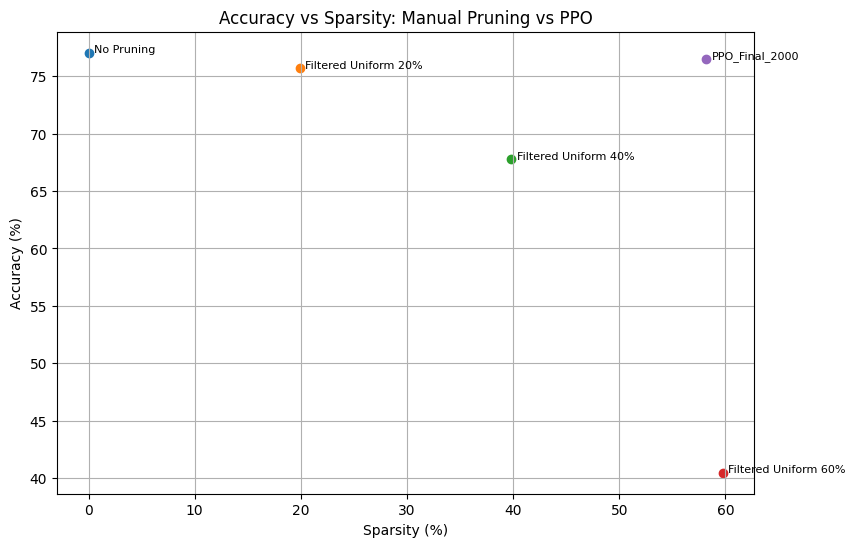

In [39]:
plt.figure(figsize=(9, 6))

for _, row in final_results_df.iterrows():
    plt.scatter(row["Sparsity (%)"], row["Accuracy (%)"])
    plt.text(
        row["Sparsity (%)"] + 0.5,
        row["Accuracy (%)"],
        row["Method"],
        fontsize=8
    )

plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Sparsity: Manual Pruning vs PPO")
plt.grid(True)
plt.show()

19. Plot Reward Comparison

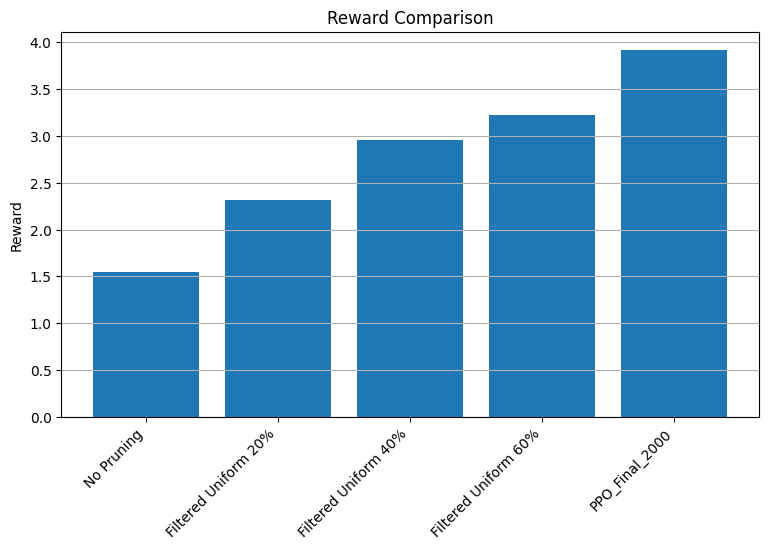

In [40]:
plt.figure(figsize=(9, 5))

plt.bar(final_results_df["Method"], final_results_df["Reward"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Reward")
plt.title("Reward Comparison")
plt.grid(axis="y")
plt.show()

20. Print Final Interpretation

In [ ]:
best_row = final_results_df.sort_values("Reward", ascending=False).iloc[0]

print("Highest reward row (reward is the training signal, not a quality metric):")
print(best_row)

print("\nResult summary:")
print(
    f"Baseline test accuracy: {baseline_accuracy:.2f}%. "
    f"PPO policy {ppo_final_result['Actions']} reached "
    f"{ppo_final_result['Accuracy (%)']:.2f}% test accuracy at "
    f"{ppo_final_result['Sparsity (%)']:.2f}% sparsity."
)

# Comparability guards. These do not assert that any method is better; they
# report when a comparison would not be like-for-like.
identical_baselines = [
    row["Method"]
    for row in filtered_manual_results
    if row["Actions"] == ppo_final_result["Actions"]
]

if identical_baselines:
    print(
        f"\nNOTE: the learned policy {ppo_final_result['Actions']} is identical to "
        f"{identical_baselines}. The two rows describe the same pruning configuration, "
        f"so any accuracy difference between them is run-to-run variation rather than "
        f"a difference between methods."
    )

matched = [
    row for row in filtered_manual_results
    if abs(row["Sparsity (%)"] - ppo_final_result["Sparsity (%)"]) < 1.0
]

if matched:
    for row in matched:
        delta = ppo_final_result["Accuracy (%)"] - row["Accuracy (%)"]
        print(
            f"\nMatched sparsity ({row['Sparsity (%)']:.2f}% vs "
            f"{ppo_final_result['Sparsity (%)']:.2f}%): PPO - {row['Method']} = {delta:+.2f} pp."
        )
else:
    print(
        f"\nNOTE: no fixed-policy baseline in this table is within 1 pp of "
        f"{ppo_final_result['Sparsity (%)']:.2f}% sparsity, so this table contains no "
        f"like-for-like comparison. See evaluation/matched_sparsity_analysis.py for "
        f"baselines generated at exactly matched sparsity."
    )

21. Optional: Run Multiple PPO Seeds

In [42]:
ppo_multi_seed_results = []

for seed in [1, 2, 3]:
    print(f"\nTraining PPO with seed={seed}")

    train_env = CompressionEnvGym(
        base_model=baseline_model,
        prunable_layers=prunable_layers_filtered,
        baseline_accuracy=baseline_val_accuracy,
        eval_loader=small_val_loader,
        device=device,
        layer_sensitivities=layer_sensitivities
    )

    eval_env = CompressionEnvGym(
        base_model=baseline_model,
        prunable_layers=prunable_layers_filtered,
        baseline_accuracy=baseline_accuracy,
        eval_loader=test_loader,
        device=device,
        layer_sensitivities=layer_sensitivities
    )

    agent = PPO(
        policy="MlpPolicy",
        env=train_env,
        verbose=0,
        learning_rate=0.0003,
        n_steps=64,
        batch_size=32,
        n_epochs=10,
        gamma=0.99,
        ent_coef=0.01,
        seed=seed
    )

    agent.learn(total_timesteps=2000)

    result = evaluate_trained_agent(
        agent=agent,
        eval_env=eval_env,
        policy_name=f"PPO_Seed_{seed}"
    )

    result["Seed"] = seed
    ppo_multi_seed_results.append(result)

ppo_multi_seed_df = pd.DataFrame(ppo_multi_seed_results)
ppo_multi_seed_df


Training PPO with seed=1


PPO_Seed_1 {'Method': 'PPO_Seed_1', 'Actions': '[0, 0, 5, 5]', 'Accuracy (%)': 76.65, 'Sparsity (%)': 57.884530999948375, 'Reward': 3.907981525600947}

Training PPO with seed=2


PPO_Seed_2 {'Method': 'PPO_Seed_2', 'Actions': '[0, 5, 5, 5]', 'Accuracy (%)': 75.16, 'Sparsity (%)': 59.66860900314904, 'Reward': 3.9503299761197304}

Training PPO with seed=3


PPO_Seed_3 {'Method': 'PPO_Seed_3', 'Actions': '[0, 5, 5, 5]', 'Accuracy (%)': 75.16, 'Sparsity (%)': 59.66860900314904, 'Reward': 3.9503299761197304}


,Method,Actions,Accuracy (%),Sparsity (%),Reward,Seed
0,PPO_Seed_1,"[0, 0, 5, 5]",76.65,57.884531,3.907982,1
1,PPO_Seed_2,"[0, 5, 5, 5]",75.16,59.668609,3.950330,2
2,PPO_Seed_3,"[0, 5, 5, 5]",75.16,59.668609,3.950330,3
